In [ ]:
import numpy as np
import os

# Parameters
base_path = "gradients_binclass"
opt_name = "AdaGramFR_nosvd"
task_name = "BinClass"
lr = 0.1
ranks = [1]
epochs = 57

# Prepare storage for each rank
rank_arrays = {rank: [] for rank in ranks}

# Load gradients for each epoch and rank
for epoch in range(epochs):
    for rank in ranks:
        filename = f"{task_name}_{opt_name}_lr{lr}_epoch{epoch}_rank{rank}_stacked.npz"
        file_path = os.path.join(base_path, filename)
        if os.path.exists(file_path):
            data = np.load(file_path)
            # Assumes the first array in the file is the gradient tensor
            tensor_np = data[data.files[0]]
            rank_arrays[rank].append(tensor_np)
        else:
            print(f"File not found: {file_path}")

# Stack arrays for each rank to get a 4D tensor: [epochs, batches, dim1, dim2]
for rank in ranks:
    if rank_arrays[rank]:
        rank_arrays[rank] = np.stack(rank_arrays[rank])  # Shape: [epochs, batches, dim1, dim2]
    else:
        rank_arrays[rank] = None

# Check the shape for each rank
for rank in ranks:
    print(f"Rank {rank}: {None if rank_arrays[rank] is None else rank_arrays[rank].shape}")


Rank 1: (57, 240, 2, 20)


In [12]:
import torch 
import numpy as np
import pandas as pd

# Example: ranks = [1, 2, 3, 4, 5], epochs = 50, each tensor shape [batches, dim1, dim2]
ranks=[1]
records = []
for r in ranks:
    for epoch in range(epochs):
        r_ep_arr = rank_arrays[r][epoch, :, :, :]  # shape: [batches, dim1, dim2]
        # Calculate variance for each batch tensor
        variances = np.var(r_ep_arr, axis=(1, 2), ddof=1)
        means = np.mean(r_ep_arr, axis=(1, 2))
        if np.isnan(r_ep_arr).any():
            print("isnan")
        if np.isinf(r_ep_arr).any():
            print("isinf")
        for batch_idx, var in enumerate(variances):
            records.append({'rank': r, 'epoch': epoch, 'batch_idx': batch_idx, 'variance': var, 'mean': means[batch_idx]})

df = pd.DataFrame(records)


In [13]:
df.head()

,rank,epoch,batch_idx,variance,mean
0,1,0,0,0.002259,-7.450581e-10
1,1,0,1,0.008497,1.490116e-09
2,1,0,2,0.004922,7.450581e-10
3,1,0,3,0.014426,1.490116e-09
4,1,0,4,0.003016,-1.862645e-10


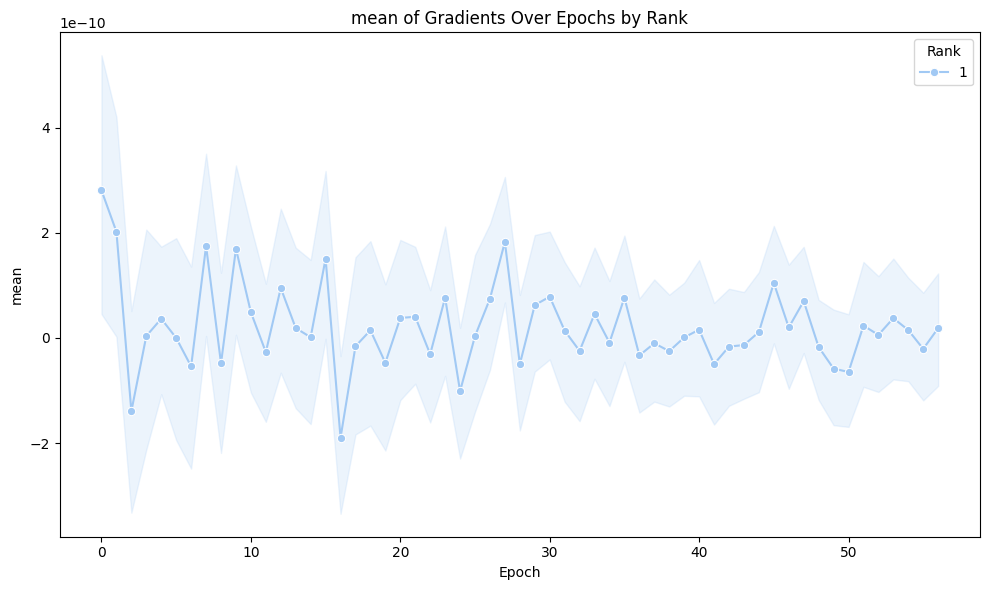

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df' and has columns: 'rank', 'epoch', 'variance'
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='epoch', y='mean', hue='rank', marker='o', palette='pastel',)

plt.xlabel('Epoch')
plt.ylabel('mean')
plt.title('mean of Gradients Over Epochs by Rank')
plt.legend(title='Rank')
plt.tight_layout()
plt.show()


In [5]:
import numpy as np
import os

# Parameters
def matrix_G_df(rank, epochs):
    base_path = "state_G_PSI"
    lr = 0.1

    # Prepare storage for each rank
    G_matrices = {epoch: [] for epoch in range(epochs)}
    G_records = []

    # Load gradients for each epoch and rank
    for epoch in range(epochs):
        filename = f"{task_name}_state_G_lr_{lr}_rank_{rank}_epoch_{epoch}.npz"
        file_path = os.path.join(base_path, filename)
        if os.path.exists(file_path):
            data = np.load(file_path)
            # Assumes the first array in the file is the gradient tensor
            tensor_np = data[data.files[0]]
            max_abs_val = np.max(abs(tensor_np))
            mean=np.mean(tensor_np)
            G_records.append({'rank': rank, 'epoch': epoch, 'max_value': max_abs_val, "mean": mean})
            G_matrices[epoch].append(tensor_np)
        else:
            print(f"File not found: {file_path}")

    df_matrix_G = pd.DataFrame(G_records)
    return df_matrix_G



In [6]:
ranks = [1, 2, 3, 4, 5]
dfs = []
epochs = 100
for rank in ranks:
    cur_df = matrix_G_df(rank, epochs)
    dfs.append(cur_df)

df = pd.concat(dfs)
df.head()

,rank,epoch,max_value,mean
0,1,0,30.310276,0.500001
1,1,1,46.796982,0.499996
2,1,2,60.207859,0.499996
3,1,3,71.802620,0.500000
4,1,4,82.327988,0.500000


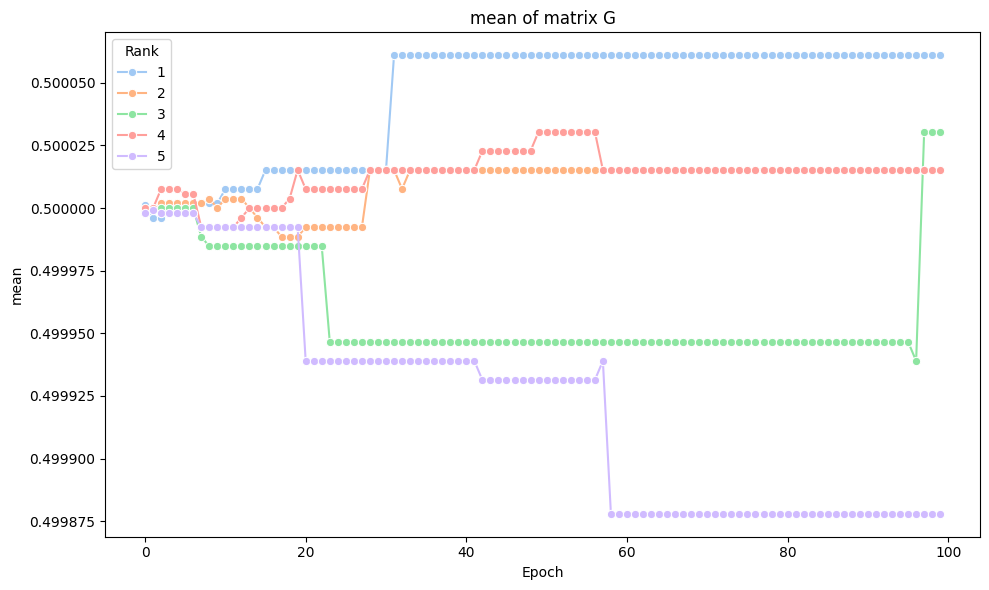

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df' and has columns: 'rank', 'epoch', 'variance'
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='epoch', y='mean', hue='rank', marker='o', palette='pastel',)

plt.xlabel('Epoch')
plt.ylabel('mean')
plt.title('mean of matrix G')
plt.legend(title='Rank')
plt.tight_layout()
plt.show()
